In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')

In [3]:
hp_data = pd.read_csv('../ML CODE/Data/house-prices-advanced-regression-techniques/train.csv')



In [4]:
hp_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
hp_data.shape

# we are having 1460 col and 81 rows

(1460, 81)

In [6]:
hp_data.info(81)



<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
hp_data.isnull().sum().sort_values(ascending=False).head(50)
hp_data.isnull().sum().value_counts(ascending=False).head(50)

0       62
81       5
37       3
38       2
259      1
1369     1
872      1
8        1
1        1
690      1
1453     1
1179     1
1406     1
Name: count, dtype: int64

In [8]:
hp_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
hp_data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [10]:
# now in this data what i can comphrehand is that the data has to many feature and  in this there are the groups od features such hass -->"BsmtQual',
    #    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
    #    'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF'"

# GarageType',
#        'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
#        'GarageCond'

# 'MoSold', 'YrSold', 'SaleType',
#        'SaleCondition'

# this all values dervies that the property is in good condition or not , we can  comprehand this common sence thing that the better the condition higher the price of it , I hypothesize that newer houses may have higher sale prices because they may require less maintenance and include more modern construction." , the bigger the klot area the higher the price it is 

#There appear to be different property classes or house styles, and they may influence price. We'll verify this using the data description.


# #  'OverallCond', 'YearBuilt', 'YearRemodAdd',
#        'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
# this all derive that the house is renovated or not , same goes with this if the house is in good condition blah blah blah

In [11]:
#-----------------EDA------------------------

hp_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: >

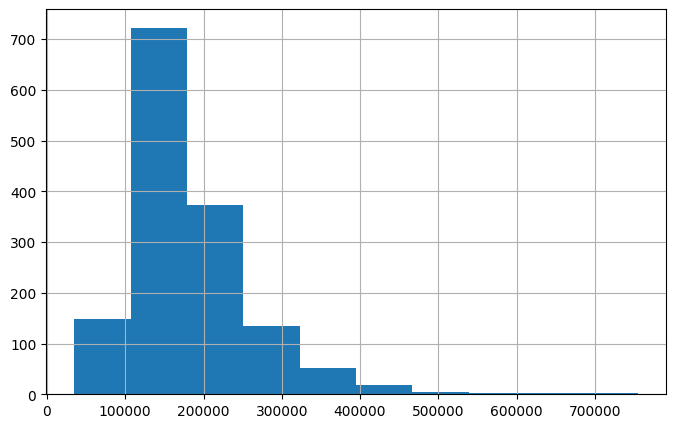

In [12]:
hp_data['SalePrice'].hist(figsize=(8,5))


In [13]:
hp_data['SalePrice'].skew()

# Skewed targets often make Linear Regression's assumptions harder to satisfy, which can reduce predictive performance.

np.float64(1.8828757597682129)

In [14]:
# ------------------------MISSIING VALUE INVESTIGATION ----------------------


missing = hp_data.isnull().sum()


missing = missing[missing > 0]

missing.sort_values(ascending=False)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [15]:
# Imagine I'm collecting information about 100 people.

# I ask:

# Do you own a car?

# Car Color?

# Person A

# Yes

# Blue

# Person B

# No

# (blank)

# Question.

# Is the blank value

# because

# I forgot to ask?

# NO.

# It's blank because

# he doesn't own a car.

# why i havent replace the data pool qc with the mode.

# Because the missing values are structural rather than accidental. A missing PoolQC value usually indicates that the house has no pool, so replacing it with the mode would incorrectly assign a pool quality to houses that don't have a pool. Instead, I would create a category such as 'None' to preserve that information.

In [16]:
# # # -------------------- classification of data --------------------
# # Type A

# # House doesn't have that feature

# # ──────────────

# # Type B

# # Someone forgot to record it

# # ──────────────

# # Type C

# # Need investigation

# PoolQC          1453 = a this also has na
# MiscFeature     1406 = a this also has na
# Alley           1369 = a i think someone forget to record it because it is  supposed to have na value if there is no alley acc to discp 
# Fence           1179 = a this also has na 
# MasVnrType       872 = a this also has na 
# FireplaceQu      690 = a this also has na 
# LotFrontage      259 = b some one might have forget to put in it okay i did my personal reasearch in it every building here is of one story , 2 stroy duplex and stuf and also some are residentionqal comercial and fv or agricault but it conclude that all must have a connected road out there property so they have forget tofill the data
#  GarageType        81 = a this also has na so there can be no garage in some property
# GarageYrBlt       81 =  same
# GarageFinish      81=  same
# GarageQual        81=  same
# GarageCond        81=  same
# BsmtExposure      38 =  same
# BsmtFinType2      38=  same
# BsmtQual          37=  same
# BsmtQual          37=  same
# BsmtCond          37=  same
# BsmtFinType1      37=  same
# MasVnrArea         8 = b its an mansonary area so there should bee some value if not theen zero but not null 
# Electrical         1 = b for this housei have check the mssub class value and its 80 so this is not unfinished so it must have cat value in it for the electrical system so they forget to record 
# dtype: int64

# note this are my obseration logically and common sence i have studied the data disc and labeled accordingf ly

In [17]:
# hp_data[[hp_data['GarageType'].isnull(),'hp_data['MSZoning']']]

hp_data[['LotFrontage', 'MSZoning']].head(50)

hp_data[hp_data['Electrical'].isnull()  == True]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1379,1380,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [18]:
# ------------CLEANING DATA ------------------------

# we can check how many nans  we have

hp_data['PoolQC'].value_counts(dropna=False)

hp_data[hp_data['PoolQC'] == 'Gd']

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1170,1171,80,RL,76.0,9880,Pave,NaN,Reg,Lvl,AllPub,...,576,Gd,GdPrv,NaN,0,7,2008,WD,Normal,171000
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
1423,1424,80,RL,NaN,19690,Pave,NaN,IR1,Lvl,AllPub,...,738,Gd,GdPrv,NaN,0,8,2006,WD,Alloca,274970


In [19]:
hp_data['PoolQC'] = hp_data['PoolQC'].fillna('None')

In [20]:
hp_data['PoolQC'].value_counts(dropna=False)

PoolQC
None    1453
Gd         3
Ex         2
Fa         2
Name: count, dtype: int64

In [21]:
#  now we have the garge data and in it well group it 


garage_cat = [
    'GarageType',
    'GarageFinish',
    'GarageQual',
    'GarageCond'
]

for col in garage_cat:
    hp_data[col] = hp_data[col].fillna('None')


# now there is one numerical col

hp_data['GarageYrBlt'] = hp_data['GarageYrBlt'].fillna(0)

In [22]:
for col in garage_cat:
    print(hp_data[col] == hp_data[col].fillna('None'))

0       True
1       True
2       True
3       True
4       True
        ... 
1455    True
1456    True
1457    True
1458    True
1459    True
Name: GarageType, Length: 1460, dtype: bool
0       True
1       True
2       True
3       True
4       True
        ... 
1455    True
1456    True
1457    True
1458    True
1459    True
Name: GarageFinish, Length: 1460, dtype: bool
0       True
1       True
2       True
3       True
4       True
        ... 
1455    True
1456    True
1457    True
1458    True
1459    True
Name: GarageQual, Length: 1460, dtype: bool
0       True
1       True
2       True
3       True
4       True
        ... 
1455    True
1456    True
1457    True
1458    True
1459    True
Name: GarageCond, Length: 1460, dtype: bool


In [23]:
hp_data[garage_cat + ['GarageYrBlt']].isnull().sum()


# hp_data[['GarageQual'],['GarageYrBlt']]
hp_data[['GarageQual','GarageYrBlt']]



,GarageQual,GarageYrBlt
0,TA,2003.0
1,TA,1976.0
2,TA,2001.0
3,TA,1998.0
4,TA,2000.0
...,...,...
1455,TA,1999.0
1456,TA,1978.0
1457,TA,1941.0
1458,TA,1950.0


In [24]:
basement_cat = [
    'BsmtExposure',
    'BsmtFinType2',
    'BsmtQual',
    'BsmtCond',
    'BsmtFinType1'
]

for col in basement_cat:
    hp_data[col] = hp_data[col].fillna('None')

In [25]:
hp_data[basement_cat].isnull().sum()

BsmtExposure    0
BsmtFinType2    0
BsmtQual        0
BsmtCond        0
BsmtFinType1    0
dtype: int64

In [26]:
# Type is categorical
hp_data['MasVnrType'] = hp_data['MasVnrType'].fillna('None')

# Area is numerical
hp_data['MasVnrArea'] = hp_data['MasVnrArea'].fillna(0)

In [27]:
hp_data['LotFrontage'] = hp_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [28]:
hp_data[['LotFrontage','Neighborhood']].head()



,LotFrontage,Neighborhood
0,65.0,CollgCr
1,80.0,Veenker
2,68.0,CollgCr
3,60.0,Crawfor
4,84.0,NoRidge


In [29]:
hp_data['LotFrontage'].isnull().sum()

np.int64(0)

In [30]:
hp_data[hp_data['LotFrontage'].isnull()][['Neighborhood','LotFrontage']]


,Neighborhood,LotFrontage


In [31]:
# we failed at fixing the nan for the 

hp_data[hp_data['Neighborhood'] == 'CollgCr'][['LotFrontage','Neighborhood']]['LotFrontage'].isnull().sum()

np.int64(0)

In [32]:
hp_data['LotFrontage'] = hp_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [33]:
hp_data['LotFrontage'].isnull().sum()

# the lesson we get from here is sometime the code is rigt the nootbook doesnt work well so we need try runing multiple times to check the creadibility 

np.int64(0)

In [34]:
hp_data['Electrical'] = hp_data['Electrical'].fillna(
    hp_data['Electrical'].mode()[0]
)


In [35]:
hp_data['Electrical'].isnull().sum()

np.int64(0)

In [36]:
hp_data.isnull().sum().sort_values(ascending=False).head(10)

MiscFeature    1406
Alley          1369
Fence          1179
FireplaceQu     690
Id                0
LotArea           0
MSSubClass        0
LotFrontage       0
MSZoning          0
Utilities         0
dtype: int64

In [37]:
type_a = ['MiscFeature', 'Alley', 'Fence', 'FireplaceQu']

for col in type_a:
    hp_data[col] = hp_data[col].fillna('None')

In [38]:
hp_data.isnull().sum().sort_values(ascending=False).head(10)


Id             0
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
Alley          0
LotShape       0
LandContour    0
Utilities      0
dtype: int64

In [39]:
# -----------------0EDA -----------------------

hp_data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: >

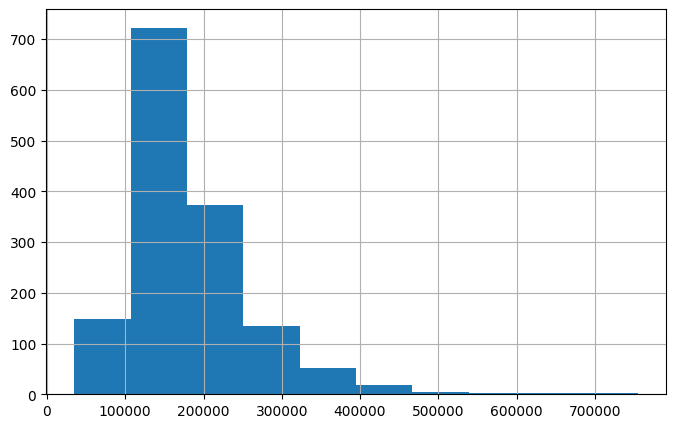

In [40]:
hp_data['SalePrice'].hist(figsize=(8,5))

In [41]:
hp_data['SalePrice'].skew()

np.float64(1.8828757597682129)

In [42]:
# lets chek the strongest numerical relationship

corr = hp_data.corr(numeric_only=True)

corr['SalePrice'].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.349876
Name: SalePrice, dtype: float64

In [43]:
# # ---------------- FEATRURE ENGINEERING ------------------

# Feature Engineering is the process of creating better information from existing information.

# Not more information.

# Better information.

In [44]:
# # hp_data = hp_data[['HalfBath','FullBath','BsmtHalfBath','BsmtFullBath']][['HalfBath','BsmtHalfBath']].replace(
# #     hp_data[['HalfBath','BsmtHalfBath']]
# # )

hp_data['HalfBath'] = hp_data['HalfBath'] * 0.5
hp_data['BsmtHalfBath'] = hp_data['BsmtHalfBath'] * 0.5

In [45]:
hp_data[['HalfBath','FullBath','BsmtHalfBath','BsmtFullBath']]

,HalfBath,FullBath,BsmtHalfBath,BsmtFullBath
0,0.5,2,0.0,1
1,0.0,2,0.5,0
2,0.5,2,0.0,1
3,0.0,1,0.0,1
4,0.5,2,0.0,1
...,...,...,...,...
1455,0.5,2,0.0,0
1456,0.0,2,0.0,1
1457,0.0,2,0.0,0
1458,0.0,1,0.0,1


In [46]:


print(hp_data.columns)

hp_data

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,...,0,None,None,None,0,4,2010,WD,Normal,142125


In [47]:
# 

hp_data['TotalBathrooms'] = (
    hp_data['FullBath']
    + 0.5 * hp_data['HalfBath']
    + hp_data['BsmtFullBath']
    + 0.5 * hp_data['BsmtHalfBath']
)

In [48]:
hp_data[['TotalBathrooms', 'FullBath', 'HalfBath']].head()

,TotalBathrooms,FullBath,HalfBath
0,3.25,2,0.5
1,2.25,2,0.0
2,3.25,2,0.5
3,2.00,1,0.0
4,3.25,2,0.5


In [49]:
# DUPLEX - ALL STYLES AND AGES
#        120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
#        150	1-1/2 STORY PUD - ALL AGES
#        160	2-STORY PUD - 1946 & NEWER
#        180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER

In [50]:
hp_data[['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF']].head()




,1stFlrSF,2ndFlrSF,TotalBsmtSF
0,856,854,856
1,1262,0,1262
2,920,866,920
3,961,756,756
4,1145,1053,1145


In [51]:
hp_data['TotalHouseSF'] = (
    hp_data['1stFlrSF']
    + hp_data['2ndFlrSF']
    + hp_data['TotalBsmtSF']
)

In [52]:
hp_data[['TotalHouseSF', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF']].head()

,TotalHouseSF,1stFlrSF,2ndFlrSF,TotalBsmtSF
0,2566,856,854,856
1,2524,1262,0,1262
2,2706,920,866,920
3,2473,961,756,756
4,3343,1145,1053,1145


In [53]:

hp_data['HouseAge'] = (
    hp_data['YrSold']
    - hp_data['YearBuilt']
)


hp_data['RemodelAge'] = (
    hp_data['YrSold']
    - hp_data['YearRemodAdd']
)


hp_data['TotalPorchSF'] = (
    hp_data['OpenPorchSF']
    + hp_data['EnclosedPorch']
    + hp_data['3SsnPorch']
    + hp_data['ScreenPorch']
)

In [54]:
hp_data[
    [
        'TotalBathrooms',
        'TotalHouseSF',
        'HouseAge',
        'RemodelAge',
        'TotalPorchSF'
    ]
].head()

,TotalBathrooms,TotalHouseSF,HouseAge,RemodelAge,TotalPorchSF
0,3.25,2566,5,5,61
1,2.25,2524,31,31,0
2,3.25,2706,7,6,42
3,2.00,2473,91,36,307
4,3.25,3343,8,8,84


In [55]:
# ------------- ENCODING ----------------------------------

hp_data.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [56]:
hp_data = pd.get_dummies(
    hp_data,
    drop_first=True,
    dtype=int
)

In [57]:
hp_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 266 entries, Id to SaleCondition_Partial
dtypes: float64(6), int64(260)
memory usage: 3.0 MB


In [58]:
# ----------- TRAIN TEST SPLIT ----------------------

X = hp_data.drop('SalePrice', axis=1)

y = hp_data['SalePrice']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.8557820477893164
MAE      : 20303.459119106974
RMSE     : 33259.566118463816


In [62]:
train_pred = model.predict(X_train)

print("Training R² :", r2_score(y_train, train_pred))
print("Testing R²  :", r2_score(y_test, y_pred))

Training R² : 0.9250709035468281
Testing R²  : 0.8557820477893164


In [63]:
# the model is over fitted by 7% 
# I compared the training and testing R² scores. The training score (92.5%) is higher than the testing score (85.6%), indicating the model has learned patterns from the training data that don't generalize perfectly to unseen data. Since the gap is around 7%, it's mild rather than severe overfitting

In [64]:
#  ------------------ MODEL IMPROVEMENT PROCESS ---------------------------

# Log Transformation -->
# Log transformation reduces the effect of extremely large values and often makes the target distribution more suitable for Linear Regression.


# 🎯 The intuition I want you to remember

# Imagine two mistakes.

# Case 1:

# Actual = ₹100,000
# Predicted = ₹150,000

# 50% error.

# Case 2:

# Actual = ₹900,000
# Predicted = ₹950,000

# About 5.5% error.

# Both are ₹50,000 apart.

# Without a log transform, Linear Regression sees them as equally bad.

# With a log transform, the first mistake is treated as much worse because it's a much larger relative error.

In [65]:
y_log = np.log1p(hp_data['SalePrice'])

In [66]:
X = hp_data.drop('SalePrice', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

In [67]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
# y applying the log transformation, we reduced the influence of extremely expensive houses. The target distribution became closer to normal, so Linear Regression could learn the overall pattern better instead of being overly influenced by a few expensive outliers.

print("R² :", r2_score(y_test, y_pred))


R² : 0.8829623043775541


In [ ]:
# ---------------------- RIDGE REGRESSION --------------------------------



In [73]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [74]:
from sklearn.metrics import r2_score

print("Training R²:", ridge.score(X_train, y_train))
print("Testing R² :", ridge.score(X_test, y_test))
print("R² Score   :", r2_score(y_test, y_pred_ridge))

Training R²: 0.9315040052522754
Testing R² : 0.8975287575489541
R² Score   : 0.8975287575489541


In [75]:
# adjusted r2

def adjusted_r2(r2, n, p):
    return 1 - ((1-r2)*(n-1)/(n-p-1))



In [76]:
n = X_test.shape[0]      # Number of test samples
p = X_test.shape[1]      # Number of features

r2 = r2_score(y_test, y_pred_ridge)
adj_r2 = adjusted_r2(r2, n, p)

print("R² Score       :", r2)
print("Adjusted R²    :", adj_r2)

R² Score       : 0.8975287575489541
Adjusted R²    : -0.14688967512516737


In [ ]:
# total evaluation


Training R² : Ellipsis
Testing R²  : Ellipsis
R² Score    : Ellipsis
Adjusted R² : Ellipsis
MAE         : Ellipsis
RMSE        : Ellipsis


In [79]:
print(X_train.shape)
print(X_test.shape)

(1168, 265)
(292, 265)


In [ ]:
# Linear Regression finds the best coefficients. Ridge finds the best coefficients while trying to keep them small.

In [80]:
# ---------------- LASSO REGRESSION ---------------------

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=10000)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [82]:
print("Training R²:", lasso.score(X_train, y_train))
print("Testing R² :", lasso.score(X_test, y_test))
print("R² Score   :", r2_score(y_test, y_pred_lasso))

Training R²: 0.7911250192133996
Testing R² : 0.8273739856939116
R² Score   : 0.8273739856939116


🏁 PROJECT 3 SUMMARY — House Price Prediction using Linear Regression

Final R² Score (Best Model - Ridge Regression + Log Transformation): 0.8975

Project Duration: ~25 Hours

🎯 Objective

The goal of this project was to predict house prices using Linear Regression while learning the complete Machine Learning workflow from raw data to model improvement. Instead of focusing only on achieving a high accuracy, the primary objective was to understand why every preprocessing step, feature engineering decision, and model improvement was performed.

📊 Dataset Overview
Rows: 1460
Columns: 81
Target Variable: SalePrice
Missing Value Columns: 18

The dataset contained numerical, categorical, and missing values, making it suitable for learning a complete regression pipeline.

🧠 Initial Business Understanding

Before writing any code, the dataset was analyzed from a business perspective.

Some logical assumptions were made:

Larger houses should generally sell for higher prices.
Better overall quality should increase the selling price.
Newer or recently renovated houses should be more expensive.
Better neighborhoods should command higher prices.
Houses with garages, basements, fireplaces, and pools should generally cost more than those without them.

These assumptions were later validated through Exploratory Data Analysis instead of being accepted blindly.

🧹 Data Cleaning

The missing values were not filled immediately.

Each column was first understood from the dataset documentation.

Examples:

PoolQC

Initially appeared to have many missing values.

After reading the documentation, it became clear that missing values actually meant:

The house does not have a pool.

Therefore:

NaN → None

instead of Median or Mode.

Garage Features

GarageType

GarageQual

GarageCond

GarageFinish

GarageYrBlt

These missing values represented houses without garages.

Filled using:

Categorical → "None"

Numerical → 0
Basement Features

Same business logic as Garage.

Missing values represented houses without basements.

LotFrontage

This became one of the biggest learning points.

Instead of using the overall median,

houses were grouped by

Neighborhood

because houses in the same neighborhood tend to have similar frontage.

Missing values were replaced using

Median LotFrontage of the same Neighborhood

instead of the global median.

📈 Exploratory Data Analysis

Several observations were made.

SalePrice Distribution
Right Skewed

Meaning:

A small number of luxury houses existed.

This observation later motivated the use of Log Transformation.

Correlation Analysis

Strongest positive features included

OverallQual
GrLivArea
GarageCars
GarageArea
TotalBsmtSF

These aligned well with business intuition.

⚙️ Feature Engineering

Instead of directly training the model, several meaningful business features were created.

TotalBathrooms
FullBath

+

0.5 × HalfBath

+

BsmtFullBath

+

0.5 × BsmtHalfBath

Reason:

Buyers care about the total usable bathrooms rather than separate basement and above-ground counts.

TotalHouseSF
1st Floor

+

2nd Floor

+

Basement Area

Reason:

Total usable living area is often more informative than individual floor sizes.

HouseAge
YrSold - YearBuilt

Reason:

People think in terms of

"How old is this house?"

rather than

"Which year was it built?"

RemodelAge
YrSold - YearRemodAdd

Captured how recently the house had been renovated.

TotalPorchSF

Combined all porch-related features into one total outdoor area.

🤖 Model Building

Several models were trained and compared.

Model 1

Linear Regression

Result

R² ≈ 0.856

Observation

Mild Overfitting

Model 2

Linear Regression

Log Transformation

Reason

SalePrice was highly right-skewed.

Applying Log Transformation reduced the influence of expensive houses and made the distribution closer to normal.

Result

R² ≈ 0.883

Improved significantly.

Model 3

Ridge Regression

Purpose

Reduce overfitting by shrinking large coefficients.

Result

Training R² = 0.931

Testing R² = 0.898

🏆 Best Model

Model 4

Lasso Regression

Purpose

Automatically remove less important features.

Result

Testing R² ≈ 0.827

Observation

Lasso became too aggressive for this dataset and underfit the data.

📊 Final Model Comparison
Model	Testing R²
Linear Regression	0.856
Linear + Log	0.883
🏆 Ridge + Log	0.898
Lasso + Log	0.827

🧠 Biggest Learnings

Throughout this project, the focus shifted from simply writing code to making engineering decisions.

Some of the key lessons learned include:

Never clean data without understanding the business.
Missing values can carry important information.
Feature Engineering can improve performance significantly.
Business intuition should always be validated using data.
Log Transformation is useful for highly skewed regression targets.
Ridge Regression helps reduce overfitting.
Different algorithms perform differently on different datasets.
Machine Learning is an experimental process rather than a guessing game.
🐞 Mistakes Made During the Project

Several mistakes were intentionally documented because they became valuable learning experiences.

Accidentally overwrote the entire DataFrame.
Mixed training and testing datasets during model fitting.
Tried to fill categorical columns using the median.
Confused features (X) with the target variable (y).
Wanted to remove low-correlation features without testing them first.

Each mistake strengthened the understanding of the complete ML workflow.

🏆 Final Conclusion

This project was not only about predicting house prices.

It was about learning how an ML engineer approaches a real-world problem:

Understanding the business before coding.
Cleaning data using logic instead of assumptions.
Validating hypotheses through EDA.
Creating meaningful features.
Comparing multiple models instead of assuming one is best.
Choosing the final model based on evidence.

The final Ridge Regression model, combined with Log Transformation, achieved the best performance with a Testing R² Score of 0.8975, making it the final selected model for this project.

Project Status: ✅ Completed